In [1]:
from pathlib import Path
import warnings 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
data_path = Path("loan_approval_dataset.csv")
df = pd.read_csv(data_path)
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
print(df.shape)
df.info()

(4269, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
print("First 5 rows:")
display(df.head())

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe())

print("\nCategorical summary:")
display(df.describe(include='object'))

First 5 rows:


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


Shape of dataset: (4269, 13)

Column names:
['loan_id', ' no_of_dependents', ' education', ' self_employed', ' income_annum', ' loan_amount', ' loan_term', ' cibil_score', ' residential_assets_value', ' commercial_assets_value', ' luxury_assets_value', ' bank_asset_value', ' loan_status']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07



Categorical summary:


,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


In [5]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [6]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in education:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Unique values in self_employed:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

Unique values in loan_status:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [7]:
# Clean categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].str.strip().str.lower()

# Remove duplicate rows
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after:", df.duplicated().sum())

# Fill missing values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = [col for col in df.select_dtypes(include='object').columns if col != 'loan_id']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Final check
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:", df.shape)

Duplicate rows before: 0
Duplicate rows after: 0

Missing values after cleaning:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Dataset shape after cleaning: (4269, 13)


Loan status distribution:
loan_status
approved    2656
rejected    1613
Name: count, dtype: int64


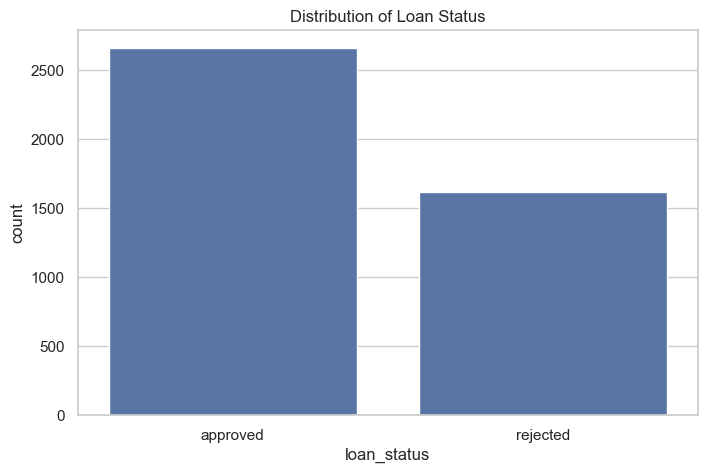

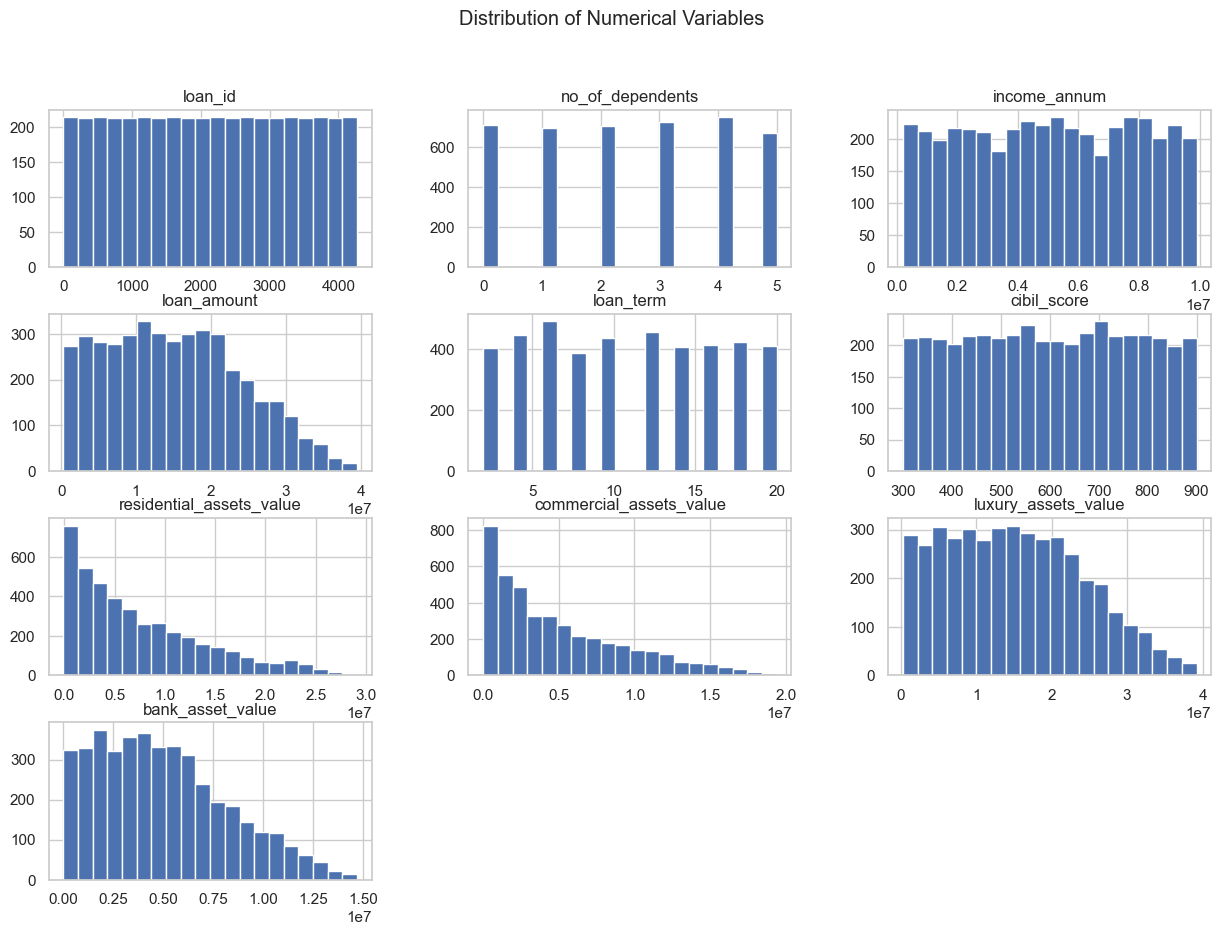

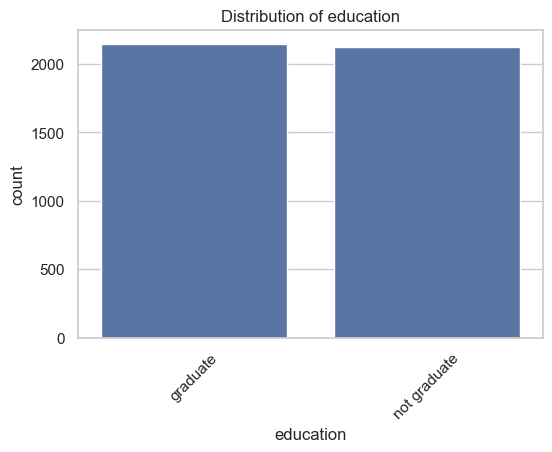

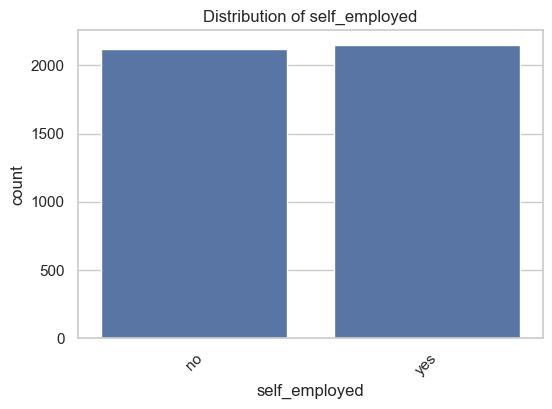

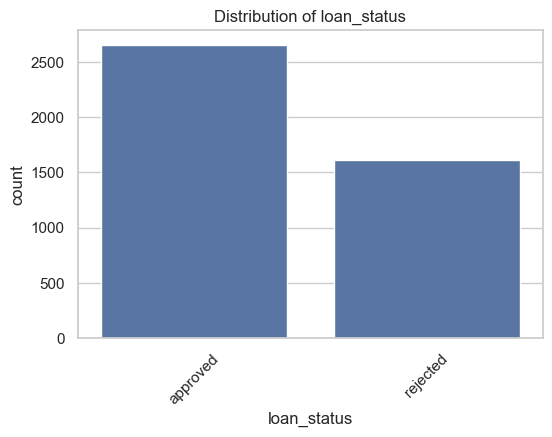

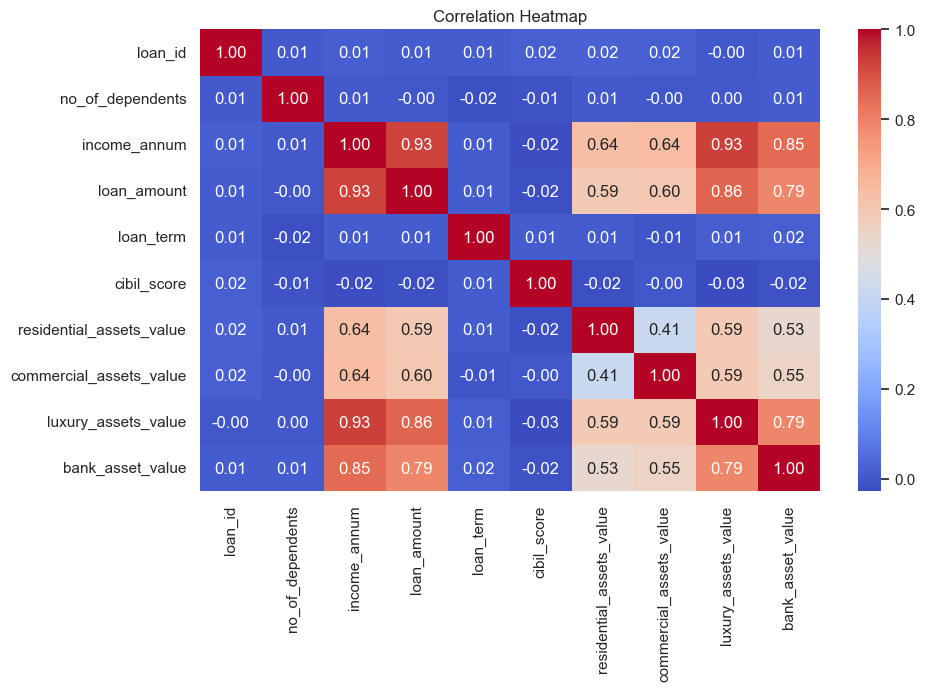

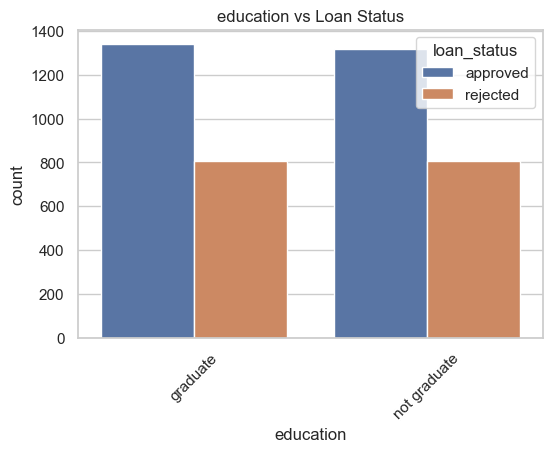

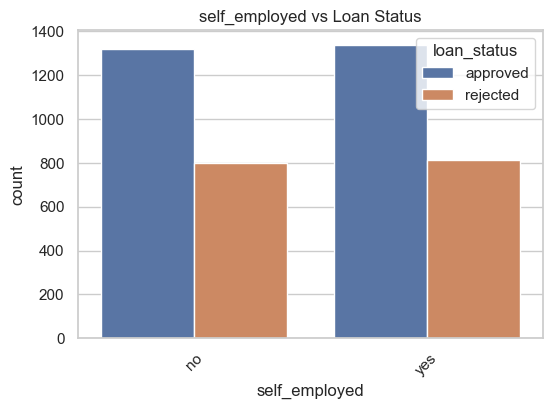

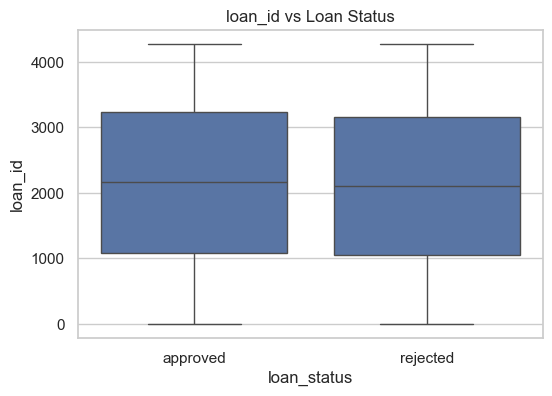

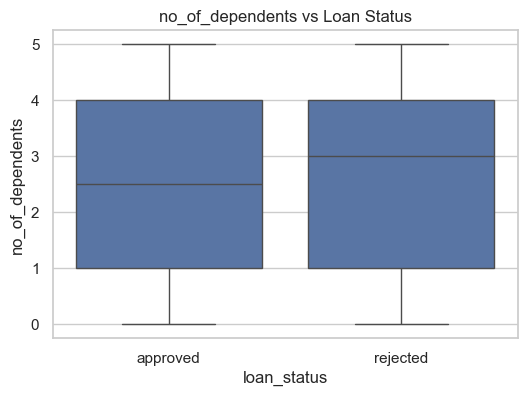

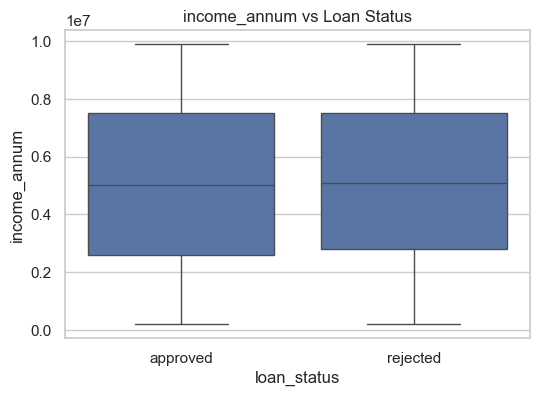

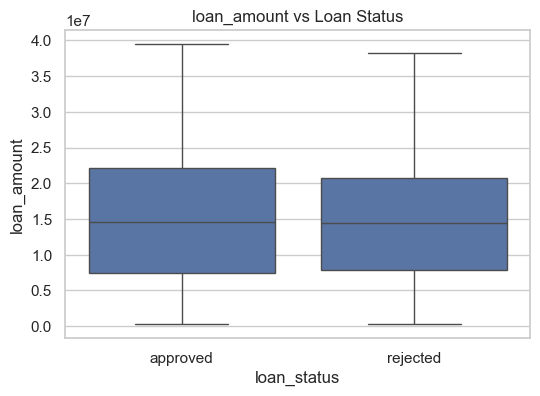

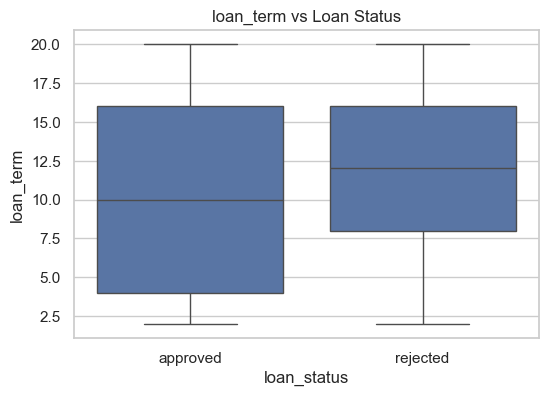

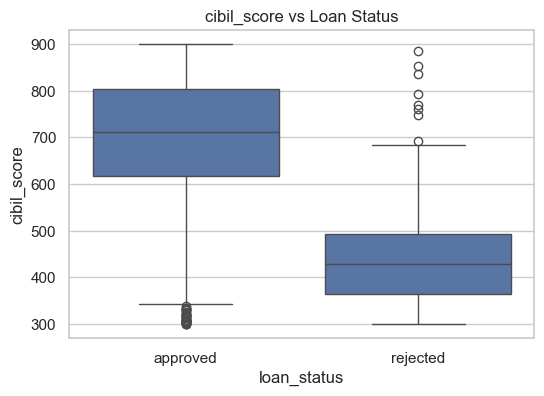

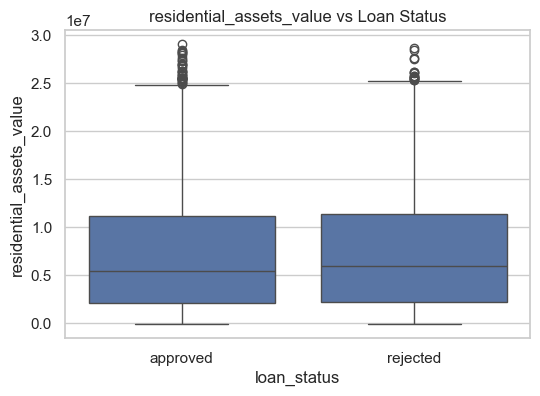

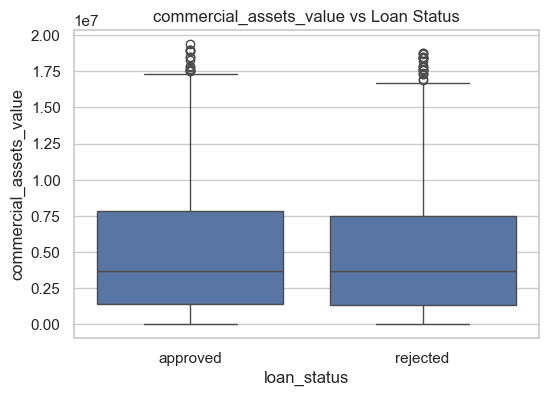

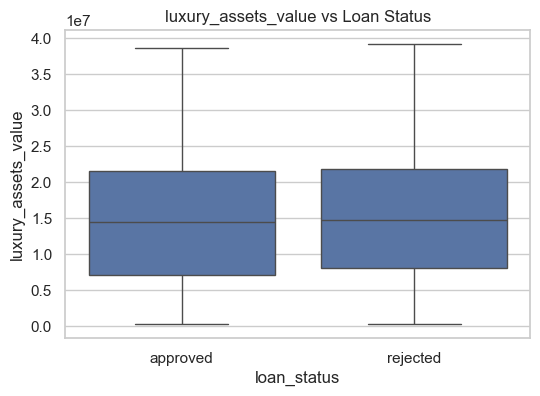

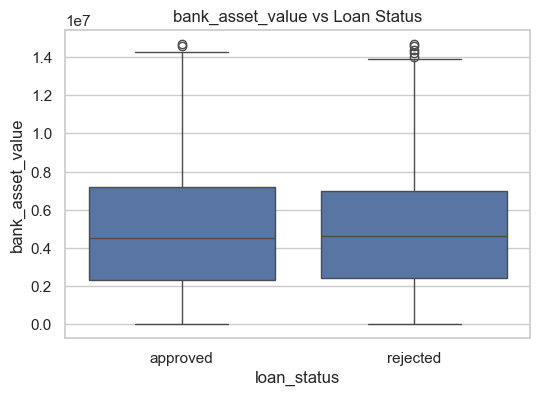

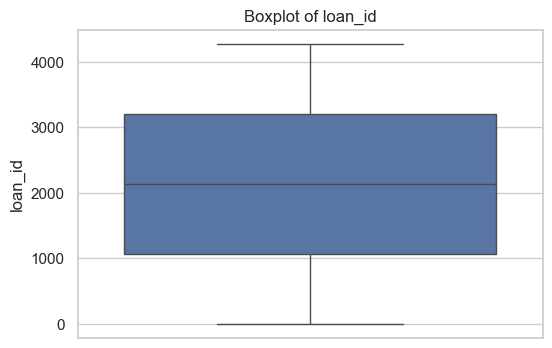

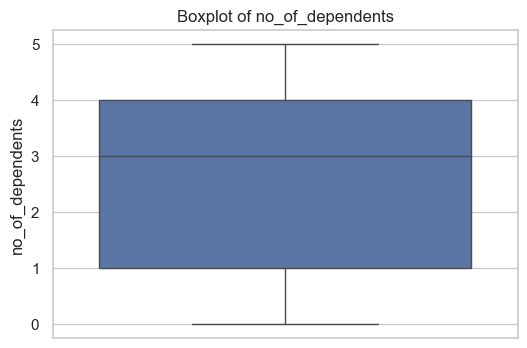

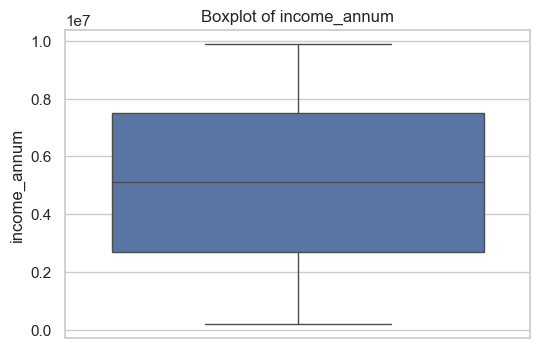

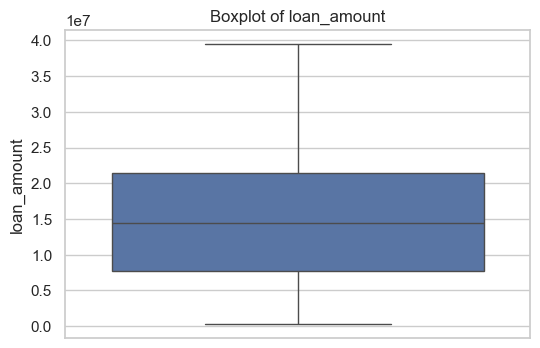

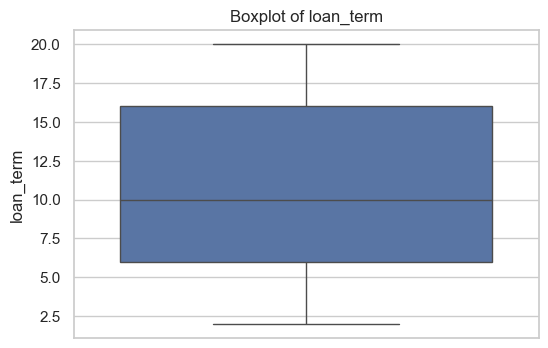

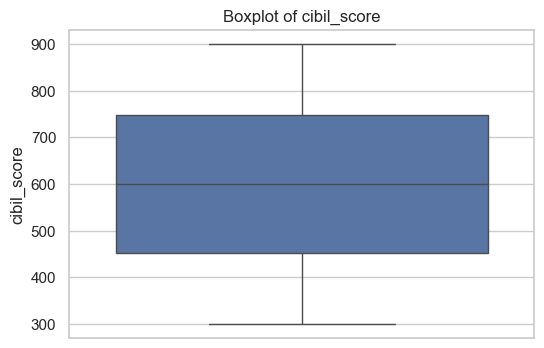

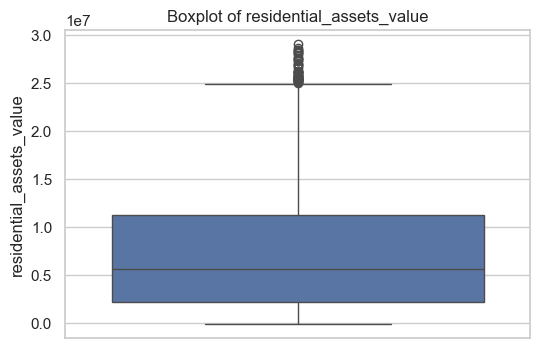

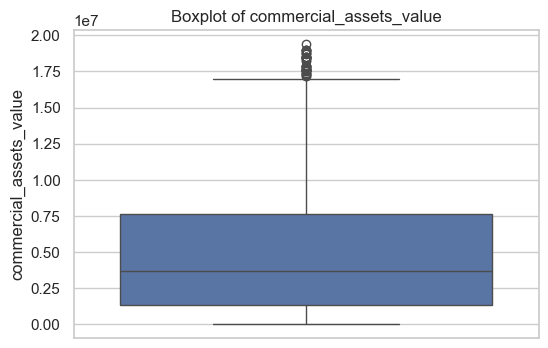

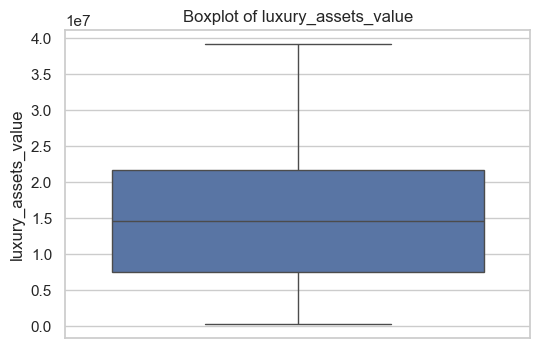

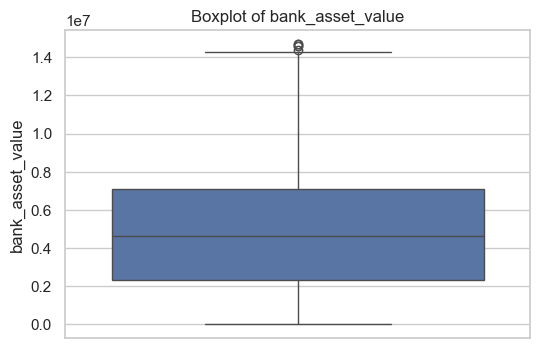

In [8]:
# Identify columns
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

# 1. Target variable distribution
print("Loan status distribution:")
print(df['loan_status'].value_counts())

sns.countplot(x='loan_status', data=df)
plt.title('Distribution of Loan Status')
plt.show()

# 2. Numerical variable distributions
df[num_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle("Distribution of Numerical Variables")
plt.show()

# 3. Categorical variable distributions
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 5. Categorical features vs target
cat_cols_no_target = [col for col in cat_cols if col != 'loan_status']

for col in cat_cols_no_target:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=45)
    plt.show()

# 6. Numerical features vs target
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f'{col} vs Loan Status')
    plt.show()

# 7. Outlier check
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define features and target
X = df.drop(['loan_status', 'loan_id'], axis=1, errors='ignore')
y = df['loan_status']

# 2. Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# 3. Encode target variable
print("Unique values in target:")
print(y.unique())

# Example mapping - adjust if necessary
y = y.map({'approved': 1, 'rejected': 0})

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Final check
print("Processed X shape:", X.shape)
print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Unique values in target:
['approved' 'rejected']
Processed X shape: (4269, 11)
Training set: (3415, 11) (3415,)
Testing set: (854, 11) (854,)



Logistic Regression Results
------------------------------
Accuracy : 0.9133
Precision: 0.9208
Recall   : 0.9416
F1-score : 0.9311

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       323
           1       0.92      0.94      0.93       531

    accuracy                           0.91       854
   macro avg       0.91      0.90      0.91       854
weighted avg       0.91      0.91      0.91       854



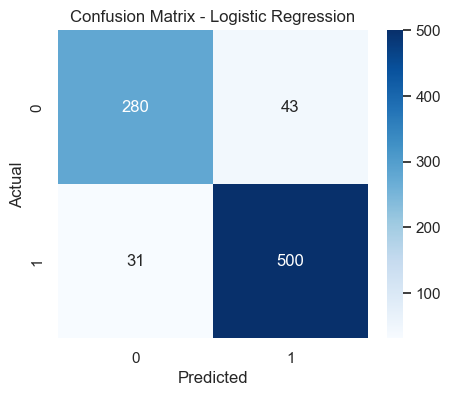


Decision Tree Results
------------------------------
Accuracy : 0.9836
Precision: 0.9832
Recall   : 0.9906
F1-score : 0.9869

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



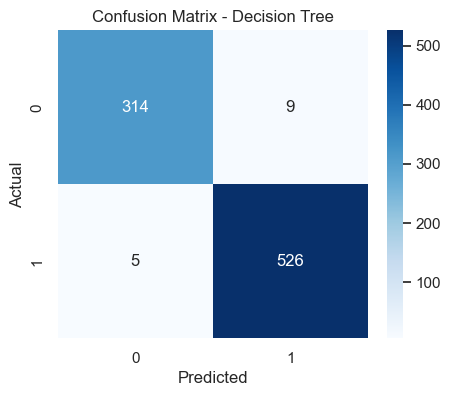


Random Forest Results
------------------------------
Accuracy : 0.9813
Precision: 0.9831
Recall   : 0.9868
F1-score : 0.985

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



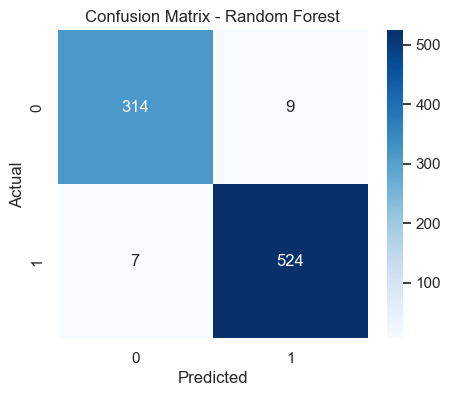


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1-score
1        Decision Tree  0.983607   0.983178  0.990584  0.986867
2        Random Forest  0.981265   0.983114  0.986817  0.984962
0  Logistic Regression  0.913349   0.920810  0.941620  0.931099


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{model_name} Results")
    print("-" * 30)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': pre,
        'Recall': rec,
        'F1-score': f1
    }


# 1. Logistic Regression
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_results = evaluate_model(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression"
)

# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_results = evaluate_model(
    dt_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree"
)

# 3. Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_results = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)

# Compare results
results_df = pd.DataFrame([log_results, dt_results, rf_results])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nModel Comparison:")
print(results_df)

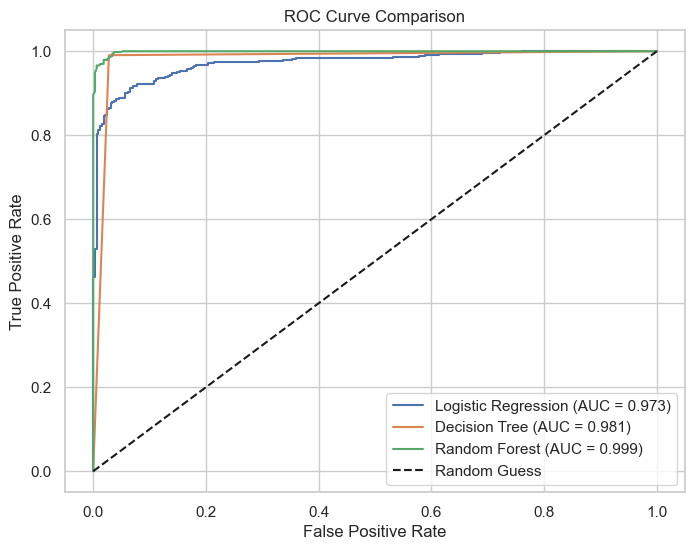

AUC Comparison:
                 Model       AUC
2        Random Forest  0.998851
1        Decision Tree  0.981360
0  Logistic Regression  0.972550

Top 10 Random Forest Important Features:
                     Feature  Importance
4                cibil_score    0.810763
3                  loan_term    0.059994
2                loan_amount    0.031523
1               income_annum    0.018853
7        luxury_assets_value    0.018456
6    commercial_assets_value    0.017192
5   residential_assets_value    0.016189
8           bank_asset_value    0.014872
0           no_of_dependents    0.007619
10         self_employed_yes    0.002285


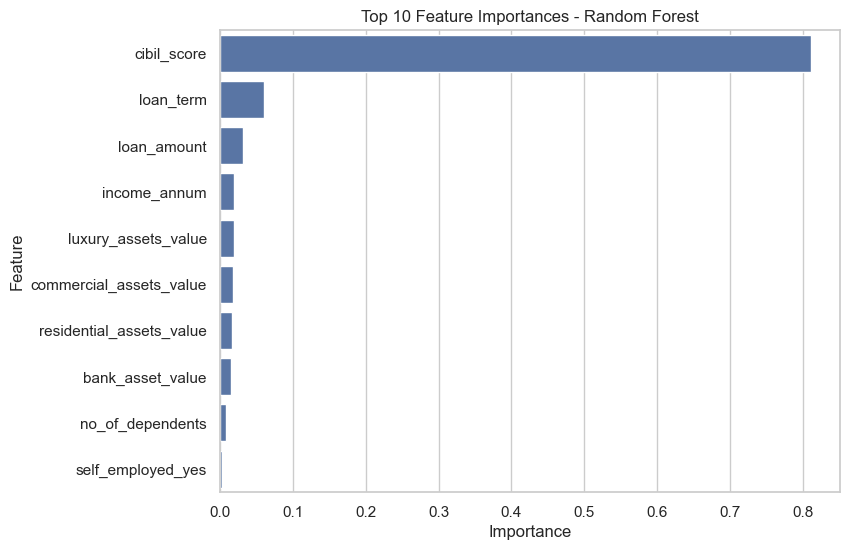


Top 10 Logistic Regression Important Features:
                    Feature  Coefficient  Abs_Coefficient
4               cibil_score     4.091076         4.091076
1              income_annum    -1.595444         1.595444
2               loan_amount     1.321432         1.321432
3                 loan_term    -0.859197         0.859197
8          bank_asset_value     0.179795         0.179795
7       luxury_assets_value     0.125665         0.125665
6   commercial_assets_value     0.093079         0.093079
0          no_of_dependents    -0.075616         0.075616
9    education_not graduate    -0.065442         0.065442
5  residential_assets_value     0.043525         0.043525


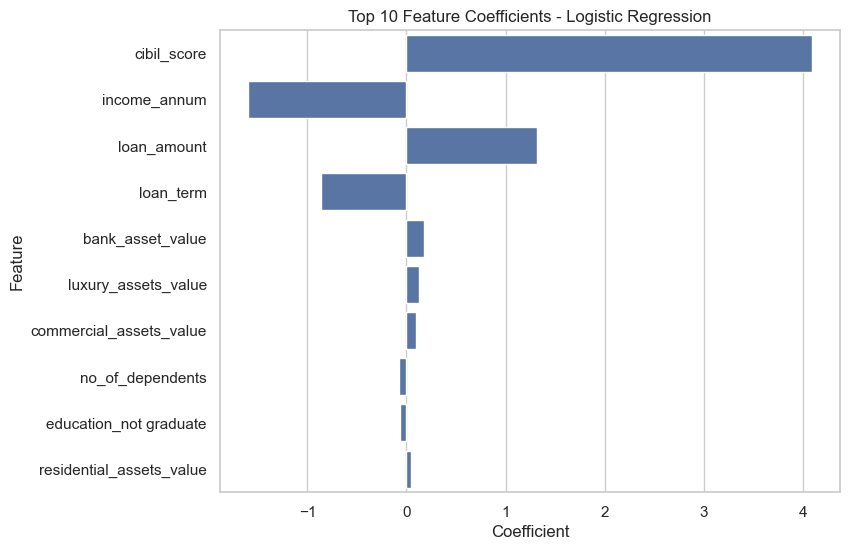

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================
# 1. Predict probabilities
# =========================
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# =========================
# 2. ROC and AUC
# =========================
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# =========================
# 3. Plot ROC comparison
# =========================
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# =========================
# 4. AUC table
# =========================
auc_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'AUC': [auc_log, auc_dt, auc_rf]
})

auc_results = auc_results.sort_values(by='AUC', ascending=False)
print("AUC Comparison:")
print(auc_results)

# =========================
# 5. Random Forest feature importance
# =========================
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

print("\nTop 10 Random Forest Important Features:")
print(feature_importance_rf.head(10))

plt.figure(figsize=(8, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_rf.head(10)
)
plt.title('Top 10 Feature Importances - Random Forest')
plt.show()

# =========================
# 6. Logistic Regression coefficients
# =========================
feature_importance_log = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

feature_importance_log['Abs_Coefficient'] = feature_importance_log['Coefficient'].abs()
feature_importance_log = feature_importance_log.sort_values(by='Abs_Coefficient', ascending=False)

print("\nTop 10 Logistic Regression Important Features:")
print(feature_importance_log.head(10))

plt.figure(figsize=(8, 6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=feature_importance_log.head(10)
)
plt.title('Top 10 Feature Coefficients - Logistic Regression')
plt.show()

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression Parameters:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-validation Score: 0.9203513909224013

Logistic Regression - Tuned Model Results
----------------------------------------
Accuracy: 0.9286

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       323
           1       0.94      0.94      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.93      0.93      0.93       854



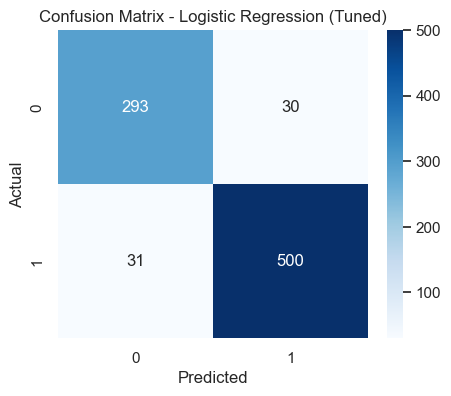

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-validation Score: 0.9792093704245973

Decision Tree - Tuned Model Results
----------------------------------------
Accuracy: 0.9824

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



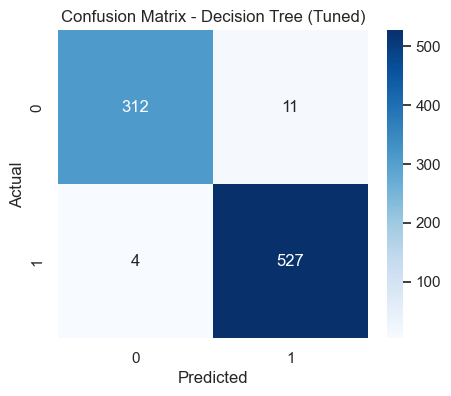

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-validation Score: 0.9815519765739384

Random Forest - Tuned Model Results
----------------------------------------
Accuracy: 0.9824

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



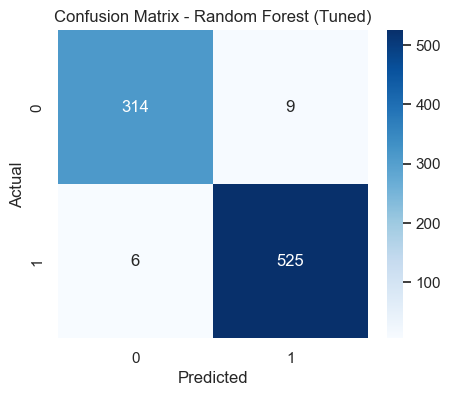


Tuned Model Comparison:
                 Model  Best CV Score
2        Random Forest       0.981552
1        Decision Tree       0.979209
0  Logistic Regression       0.920351


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def evaluate_tuned_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"\n{model_name} - Tuned Model Results")
    print("-" * 40)
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name} (Tuned)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# =========================
# 1. Logistic Regression
# =========================
log_model = LogisticRegression(max_iter=1000, random_state=42)

param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid_log = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid_log,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_log.fit(X_train_scaled, y_train)

print("Best Logistic Regression Parameters:")
print(grid_log.best_params_)
print("Best Cross-validation Score:", grid_log.best_score_)

best_log_model = grid_log.best_estimator_

evaluate_tuned_model(
    best_log_model,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)


# =========================
# 2. Decision Tree
# =========================
dt_model = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("\nBest Decision Tree Parameters:")
print(grid_dt.best_params_)
print("Best Cross-validation Score:", grid_dt.best_score_)

best_dt_model = grid_dt.best_estimator_

evaluate_tuned_model(
    best_dt_model,
    X_test,
    y_test,
    "Decision Tree"
)


# =========================
# 3. Random Forest
# =========================
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(grid_rf.best_params_)
print("Best Cross-validation Score:", grid_rf.best_score_)

best_rf_model = grid_rf.best_estimator_

evaluate_tuned_model(
    best_rf_model,
    X_test,
    y_test,
    "Random Forest"
)


# =========================
# 4. Compare tuned models
# =========================
tuned_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Best CV Score': [
        grid_log.best_score_,
        grid_dt.best_score_,
        grid_rf.best_score_
    ]
})

tuned_results = tuned_results.sort_values(by='Best CV Score', ascending=False)

print("\nTuned Model Comparison:")
print(tuned_results)

Tuned Model Comparison:
                 Model  Best_CV_Score
2        Random Forest       0.981552
1        Decision Tree       0.979209
0  Logistic Regression       0.920351

Best Model Selected: Random Forest

Final Model: Random Forest
----------------------------------------
Accuracy : 0.9824
Precision: 0.9831
Recall   : 0.9887
F1-score : 0.9859
AUC      : 0.9988

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



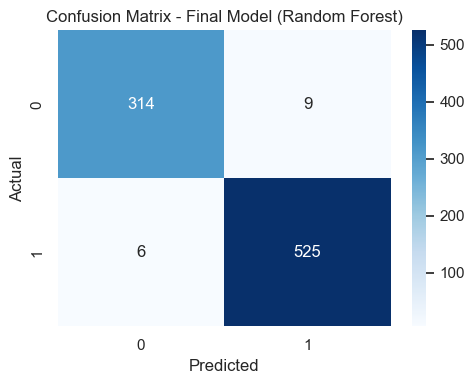

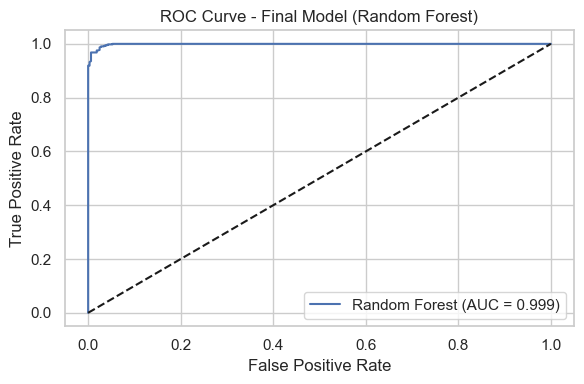

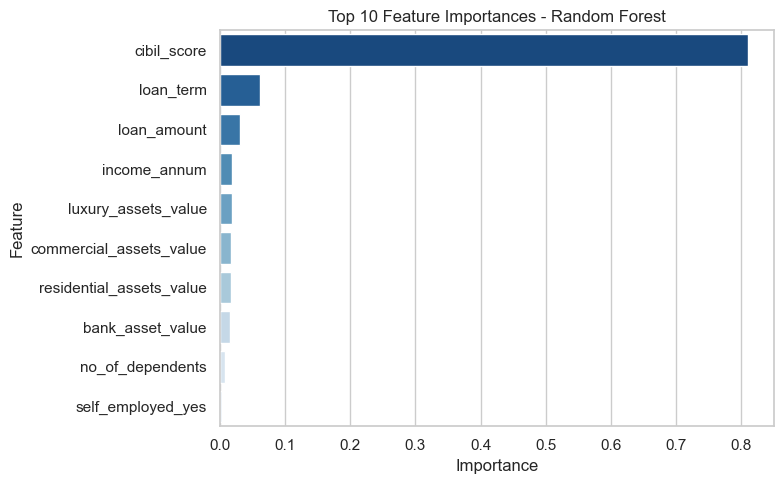


Deployment package saved as deployment_package.pkl


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# =========================
# 1. Compare tuned models
# =========================
final_compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Best_CV_Score': [
        grid_log.best_score_,
        grid_dt.best_score_,
        grid_rf.best_score_
    ]
})

final_compare = final_compare.sort_values(by='Best_CV_Score', ascending=False)

print("Tuned Model Comparison:")
print(final_compare)

# =========================
# 2. Select best model
# =========================
best_model_name = final_compare.iloc[0]['Model']
print("\nBest Model Selected:", best_model_name)

if best_model_name == 'Logistic Regression':
    final_model = best_log_model
    X_test_final = X_test_scaled
    scaler_to_save = scaler   # 这里假设你前面已经定义了 scaler
elif best_model_name == 'Decision Tree':
    final_model = best_dt_model
    X_test_final = X_test
    scaler_to_save = None
else:
    final_model = best_rf_model
    X_test_final = X_test
    scaler_to_save = None

# =========================
# 3. Final evaluation
# =========================
y_pred_final = final_model.predict(X_test_final)
y_prob_final = final_model.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test, y_pred_final)
pre = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_prob_final)

print(f"\nFinal Model: {best_model_name}")
print("-" * 40)
print("Accuracy :", round(acc, 4))
print("Precision:", round(pre, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))
print("AUC      :", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# =========================
# 4. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - Final Model ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# =========================
# 5. ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - Final Model ({best_model_name})')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 6. Feature Importance
# =========================
if best_model_name in ['Decision Tree', 'Random Forest']:
    importances = final_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='Blues_r')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

# =========================
# 7. Save deployment package
# =========================
deployment_package = {
    "model_name": best_model_name,
    "model": final_model,
    "feature_columns": X_train.columns.tolist(),
    "scaler": scaler_to_save,
    "metrics": {
        "accuracy": round(acc, 4),
        "precision": round(pre, 4),
        "recall": round(rec, 4),
        "f1_score": round(f1, 4),
        "auc": round(auc, 4)
    }
}

with open("deployment_package.pkl", "wb") as f:
    pickle.dump(deployment_package, f)

print("\nDeployment package saved as deployment_package.pkl")

Tuned Model Comparison:
                 Model  Best_CV_Score
2        Random Forest       0.981552
1        Decision Tree       0.979209
0  Logistic Regression       0.920351

Best Model Selected: Random Forest

Final Model: Random Forest
----------------------------------------
Accuracy : 0.9824
Precision: 0.9831
Recall   : 0.9887
F1-score : 0.9859
AUC      : 0.9988

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



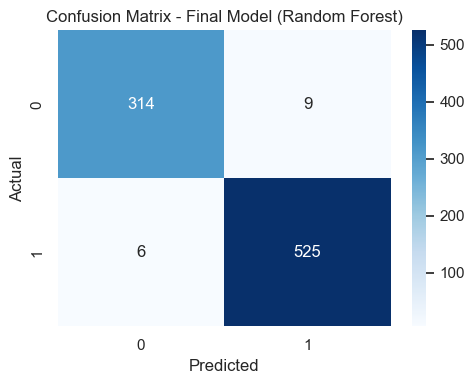

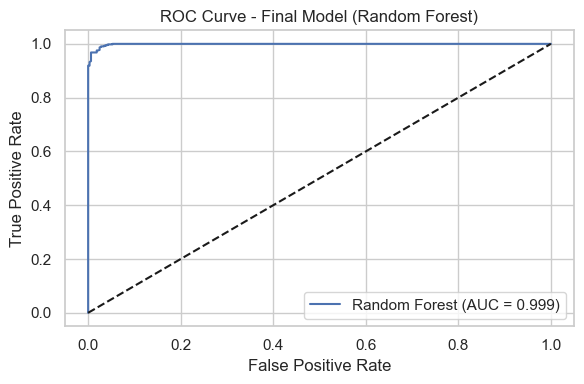

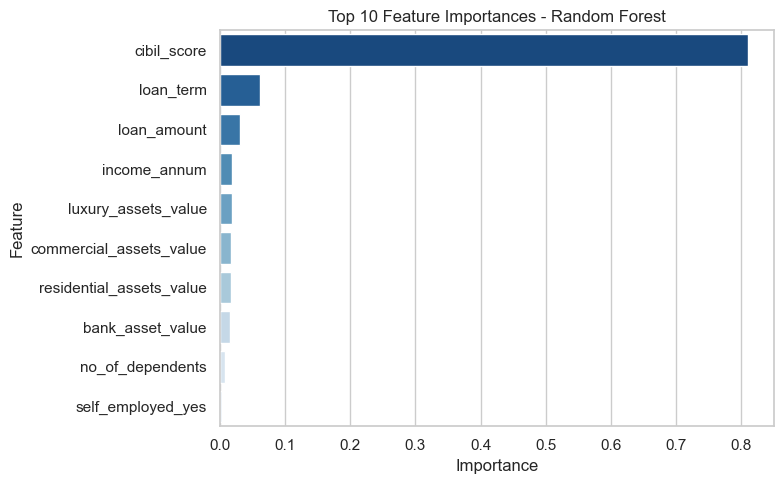


Deployment package saved as deployment_package.pkl


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# =========================
# 1. Compare tuned models
# =========================
final_compare = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Best_CV_Score': [
        grid_log.best_score_,
        grid_dt.best_score_,
        grid_rf.best_score_
    ]
})

final_compare = final_compare.sort_values(by='Best_CV_Score', ascending=False)

print("Tuned Model Comparison:")
print(final_compare)

# =========================
# 2. Select best model
# =========================
best_model_name = final_compare.iloc[0]['Model']
print("\nBest Model Selected:", best_model_name)

if best_model_name == 'Logistic Regression':
    final_model = best_log_model
    X_test_final = X_test_scaled
    scaler_to_save = scaler   
elif best_model_name == 'Decision Tree':
    final_model = best_dt_model
    X_test_final = X_test
    scaler_to_save = None
else:
    final_model = best_rf_model
    X_test_final = X_test
    scaler_to_save = None

# =========================
# 3. Final evaluation
# =========================
y_pred_final = final_model.predict(X_test_final)
y_prob_final = final_model.predict_proba(X_test_final)[:, 1]

acc = accuracy_score(y_test, y_pred_final)
pre = precision_score(y_test, y_pred_final)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_prob_final)

print(f"\nFinal Model: {best_model_name}")
print("-" * 40)
print("Accuracy :", round(acc, 4))
print("Precision:", round(pre, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))
print("AUC      :", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# =========================
# 4. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - Final Model ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# =========================
# 5. ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - Final Model ({best_model_name})')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 6. Feature Importance
# =========================
if best_model_name in ['Decision Tree', 'Random Forest']:
    importances = final_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='Blues_r')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

# =========================
# 7. Save deployment package
# =========================
deployment_package = {
    "model_name": best_model_name,
    "model": final_model,
    "feature_columns": X_train.columns.tolist(),
    "scaler": scaler_to_save,
    "metrics": {
        "accuracy": round(acc, 4),
        "precision": round(pre, 4),
        "recall": round(rec, 4),
        "f1_score": round(f1, 4),
        "auc": round(auc, 4)
    }
}

with open("deployment_package.pkl", "wb") as f:
    pickle.dump(deployment_package, f)

print("\nDeployment package saved as deployment_package.pkl")

In [20]:
import joblib

joblib.dump(final_model, 'best_loan_model.pkl')
print("Model saved successfully.")

Model saved successfully.


In [21]:
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')
print("Feature columns saved successfully.")

Feature columns saved successfully.
